# 00 · PJM Energy Demand — Acquisition & Cleaning

## Part 0 — Acquisition & Cleaning

**The dataset.** Sixteen years (2002–2018) of **hourly electricity demand** for the PJM
Interconnection — the grid operator coordinating power across 13 US states from the mid-Atlantic to
the Midwest. Eleven columns are regional zones; demand is in **megawatts (MW)**. We model **PJME**
(PJM East), the longest, cleanest zone.

**Why this dataset is a time-series showcase.** Electricity demand is the textbook example of *rich*
temporal structure, all at once:
- **Triple seasonality** — a *daily* cycle (people wake, work, sleep), a *weekly* cycle (weekday vs
  weekend), and an *annual* cycle.
- **Bimodal annual** — unlike most series, demand peaks **twice** a year: winter (heating) and summer
  (air-conditioning), with mild spring/autumn troughs.
- **Weather-driven extremes** — heat waves and cold snaps drive the peaks that grids are sized for.
- **Local-time artifacts** — the data is in wall-clock time, so **daylight-saving** transitions create
  duplicate and missing hours that must be cleaned.

This part assembles the panel, audits and fixes the data-quality issues, and produces the clean,
gap-free series the rest of the study uses.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 130, "display.max_columns", 40)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)


setup ok | numpy 2.1.3 | pandas 2.3.3


### 1. The regional panel

The raw data is one CSV per zone; `data.load_panel()` returns them aligned on a single hourly index.
The zones cover **different spans** (PJME runs the full 16 years; smaller zones start later), so the
wide panel is intentionally *ragged* — full where a zone reported, `NaN` before it existed.

In [2]:
panel = data.load_panel()
print("panel shape:", panel.shape, "| span:", panel.index.min(), "->", panel.index.max())
print("\ncoverage per zone (non-null hours):")
print(panel.notna().sum().sort_values(ascending=False).to_string())

panel shape: (145362, 11) | span: 2002-01-01 01:00:00 -> 2018-08-03 00:00:00

coverage per zone (non-null hours):
PJME      145362
PJMW      143202
DAYTON    121271
AEP       121269
DUQ       119064
DOM       116185
COMED      66493
FE         62870
NI         58450
DEOK       57735
EKPC       45330


### 2. Data-quality audit — the daylight-saving trap

Demand is recorded in **local wall-clock time**. Twice a year that bites:
- **Autumn "fall back"** repeats the 1–2 am hour → **duplicate timestamps** (removed during assembly,
  keeping the first).
- **Spring "spring forward"** skips an hour → **missing timestamps**.

Building the *complete* hourly grid exposes the gaps. They're few (≈30 hours over 16 years) but must be
filled, or every seasonal calculation silently misaligns.

In [3]:
s_raw = panel[data.PRIMARY]
full_grid = pd.date_range(s_raw.index.min(), s_raw.index.max(), freq="h")
missing = full_grid.difference(s_raw.index)
print("PJME reported hours:", s_raw.notna().sum())
print("complete hourly grid:", len(full_grid))
print("MISSING hours (DST spring-forward + gaps):", len(missing))
print("examples:", [str(t) for t in missing[:4]])

PJME reported hours: 145362
complete hourly grid: 145392
MISSING hours (DST spring-forward + gaps): 30
examples: ['2002-04-07 03:00:00', '2002-10-27 02:00:00', '2003-04-06 03:00:00', '2003-10-26 02:00:00']


### 3. The clean primary series

`data.primary()` drops any duplicate timestamps, reindexes onto the complete hourly grid, and fills
the few missing hours by **time interpolation** (linear in time — appropriate for a smooth, strongly
autocorrelated load curve). The result is a continuous hourly MW series with no gaps.

In [4]:
s = data.primary()
print("clean series:", s.shape, "| any missing:", int(s.isna().sum()), "| freq:", s.index.freq)
print("MW — mean %.0f | median %.0f | min %.0f | max %.0f" % (s.mean(), s.median(), s.min(), s.max()))

clean series: (145392,) | any missing: 0 | freq: <Hour>
MW — mean 32079 | median 31420 | min 14544 | max 62009


### 4. First look — two weeks of demand

A fortnight makes the **daily** and **weekly** rhythms visible at once: a smooth sinusoid each day
(trough ~4 am, peak in the evening) and a clear drop across the two weekends. This is the structure
the whole study will dissect.

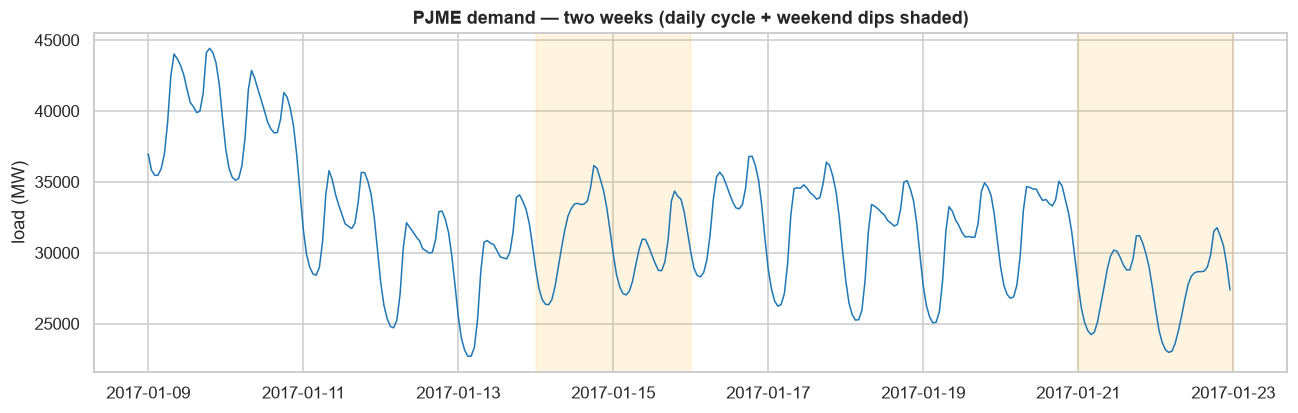

In [5]:
win = s.loc["2017-01-09":"2017-01-22"]
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(win.index, win.values, color="tab:blue", lw=1)
for d0 in pd.date_range("2017-01-14", "2017-01-22", freq="D"):
    if d0.dayofweek == 5: ax.axvspan(d0, d0 + pd.Timedelta(days=2), color="orange", alpha=.12)
ax.set_ylabel("load (MW)"); ax.set_title("PJME demand — two weeks (daily cycle + weekend dips shaded)")
eda.savefig(fig, "p0_fortnight.png"); plt.show()

### 5. Calendar features & persistence

Electricity demand is *driven by the calendar* (clock, weekday, season, holidays), so we attach those
features now and persist the modelling-ready table. `is_holiday` uses the US federal calendar — demand
on holidays behaves like an extra weekend.

In [6]:
d = data.build_processed()
print("saved data/processed/pjme_clean.csv:", d.shape)
print("columns:", list(d.columns))
print("holidays flagged:", int(d.is_holiday.sum()), "hours |", int(d.is_holiday.sum()/24), "days over 16 years")

saved data/processed/pjme_clean.csv: (145392, 8)
columns: ['load_mw', 'hour', 'dow', 'month', 'year', 'is_weekend', 'is_holiday', 'season']
holidays flagged: 4391 hours | 182 days over 16 years


### Takeaways

- **16 years × hourly** PJME demand, plus 10 other zones (ragged coverage) for later multivariate work.
- The **local-time / DST trap** is real: duplicate timestamps (dropped) and ~30 missing hours
  (interpolated). Handling it is a prerequisite for any seasonal analysis.
- The clean series ranges **14,544 → 62,009 MW**; calendar features (hour, day-of-week, month, holiday,
  season) are attached.
- Two weeks already reveal the **daily + weekly** cycles — Part 1 quantifies the full seasonal
  structure.

**Next — Part 1 (Advanced EDA I):** the demand distribution and the complete calendar anatomy — the
triple seasonality, the summer-vs-winter daily shapes, weekend/holiday effects, and the load-duration
curve.